# MODELLING 


# IMPORT CÁC THƯ VIỆN CẦN THIẾT 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NẠP DỮ LIỆU 

In [2]:
print(" Đang khởi động hệ thống và nạp dữ liệu Siêu bảng...")

# 1. NẠP DỮ LIỆU TỪ FILE PICKLE
# Lưu ý: Dùng ../ để lùi ra khỏi thư mục source_code, đi vào thư mục dataset
df_master = pd.read_pickle('../dataset/customer_master_clean.pkl')

# 2. KIỂM TRA NHANH KẾT QUẢ
print(f" Đã nạp thành công! Kích thước bộ dữ liệu hiện tại: {df_master.shape[0]} khách hàng và {df_master.shape[1]} đặc trưng.")
print("-" * 70)

# Hiển thị 5 dòng đầu tiên để đảm bảo mọi thứ vẫn nguyên vẹn
display(df_master.head())

 Đang khởi động hệ thống và nạp dữ liệu Siêu bảng...
 Đã nạp thành công! Kích thước bộ dữ liệu hiện tại: 297 khách hàng và 8 đặc trưng.
----------------------------------------------------------------------


,client_id,Recency,Frequency,Monetary,current_age,yearly_income,credit_score,total_debt
0,0,1,601,35520.89,33,59613,763,36199
1,1,3,422,15367.13,43,45360,704,14587
2,2,4,469,15687.60,48,27447,673,80850
3,3,4,302,14334.53,49,27943,681,18693
4,4,3,667,30414.66,54,76431,716,115362


In [4]:
df_master.sample(20)

,client_id,Recency,Frequency,Monetary,current_age,yearly_income,credit_score,total_debt
19,33,5,442,22889.62,77,38692,596,8902
61,96,1,1497,135945.20,69,99825,685,4344
133,207,20,202,12702.98,73,28553,745,19507
258,437,4,414,27523.29,46,72670,718,28915
206,343,3,423,17414.00,55,47643,764,45706
37,58,2,387,21477.10,38,52512,706,95640
222,369,1,594,43556.10,39,51499,788,7226
38,59,4,581,16517.18,85,25066,695,424
177,282,2,347,10090.54,42,25585,702,59827
247,415,3,322,11521.93,53,33729,763,0


In [4]:
df_master.shape

(297, 8)

In [5]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   client_id      297 non-null    int64  
 1   Recency        297 non-null    int64  
 2   Frequency      297 non-null    int64  
 3   Monetary       297 non-null    float64
 4   current_age    297 non-null    int64  
 5   yearly_income  297 non-null    int64  
 6   credit_score   297 non-null    int64  
 7   total_debt     297 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 18.7 KB


In [6]:
df_master.isnull().sum()

client_id        0
Recency          0
Frequency        0
Monetary         0
current_age      0
yearly_income    0
credit_score     0
total_debt       0
dtype: int64

# DATA UNDERSTANDING 

# 1. Kiểm tra Missing Values 

🔍 ĐANG QUÉT DỮ LIỆU RỖNG TRÊN SIÊU BẢNG...

1. Bảng thống kê số lượng ô trống theo từng cột:


,Số ô rỗng (NaN)
client_id,0
Recency,0
Frequency,0
Monetary,0
current_age,0
yearly_income,0
credit_score,0
total_debt,0



2. Đang vẽ Bản đồ nhiệt báo cáo...


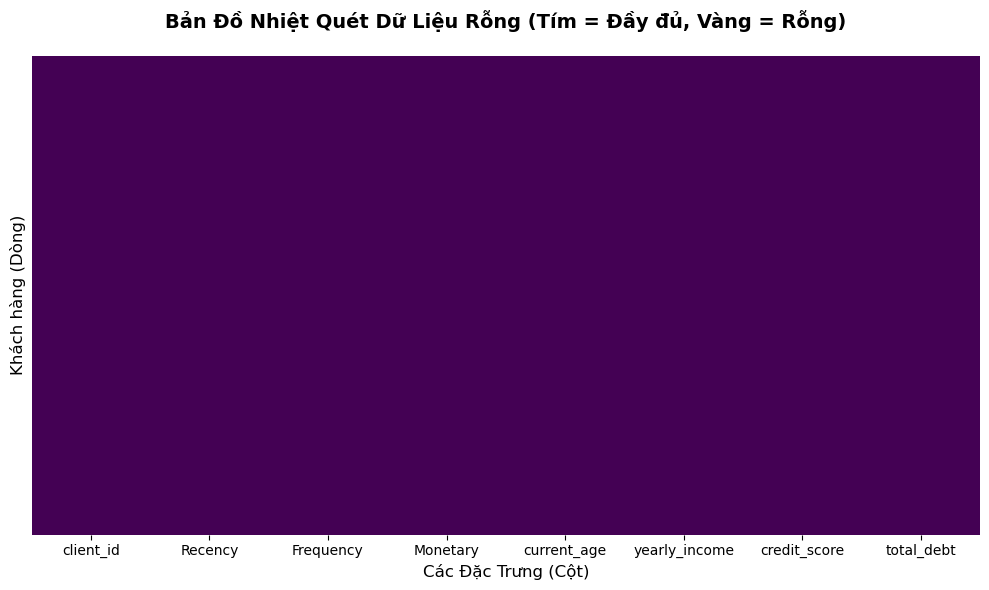

----------------------------------------------------------------------


In [5]:
# ==============================================================================
# KIỂM TRA VÀ TRỰC QUAN HÓA DỮ LIỆU RỖNG (MISSING VALUES) TRÊN DF_MASTER
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("🔍 ĐANG QUÉT DỮ LIỆU RỖNG TRÊN SIÊU BẢNG...\n")

# 1. BÁO CÁO BẰNG SỐ LIỆU TỔNG HỢP
missing_data = df_master.isnull().sum()
print("1. Bảng thống kê số lượng ô trống theo từng cột:")
display(pd.DataFrame({'Số ô rỗng (NaN)': missing_data}))

# 2. TRỰC QUAN HÓA BẰNG BẢN ĐỒ NHIỆT (MISSING VALUE HEATMAP)
print("\n2. Đang vẽ Bản đồ nhiệt báo cáo...")
plt.figure(figsize=(10, 6))

# Vẽ heatmap cho các giá trị rỗng. 
# Màu nền sẽ thể hiện dữ liệu đầy đủ, các vệt màu sáng sẽ nổi lên nếu có dữ rỗng.
sns.heatmap(df_master.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Bản Đồ Nhiệt Quét Dữ Liệu Rỗng (Tím = Đầy đủ, Vàng = Rỗng)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Các Đặc Trưng (Cột)', fontsize=12)
plt.ylabel('Khách hàng (Dòng)', fontsize=12)

plt.tight_layout()
plt.show()

print("-" * 70)

# 2. Kiểm tra Outliers 

🔍 ĐANG VẼ BIỂU ĐỒ TÌM ĐIỂM DỊ BIỆT (OUTLIERS)...



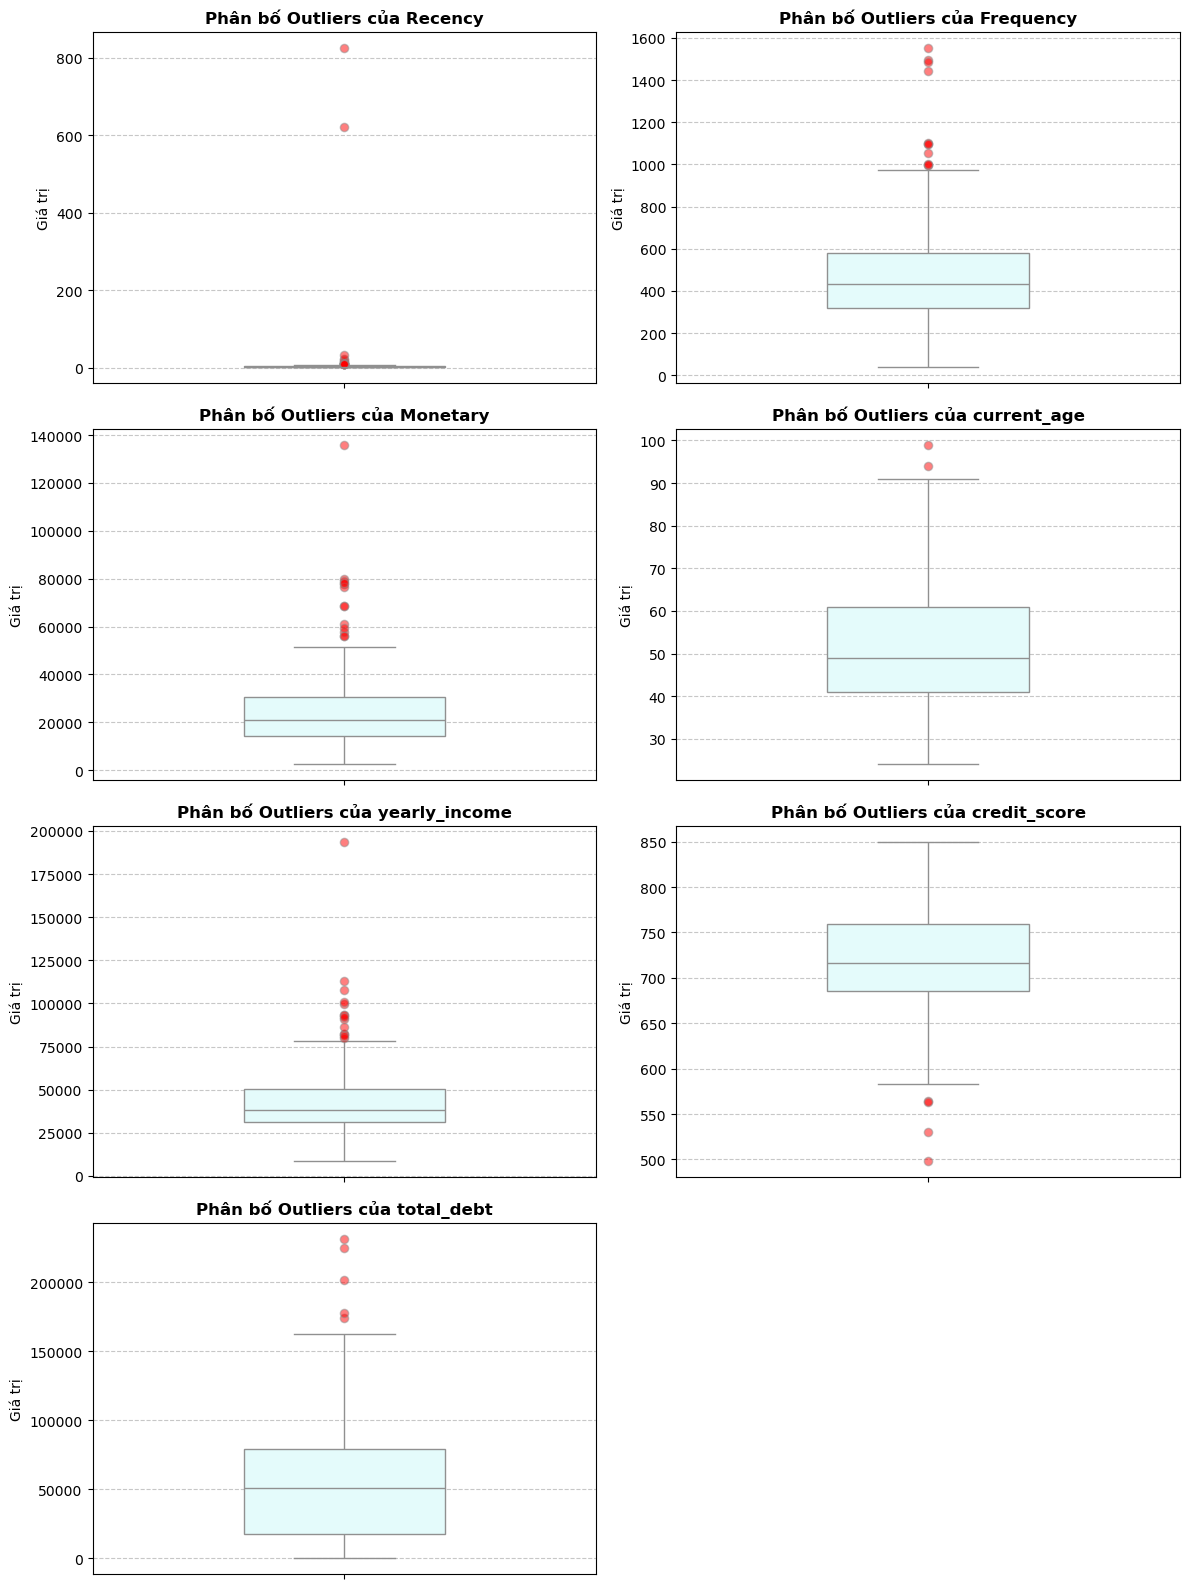

--------------------------------------------------------------------------------
✅ Hoàn tất! Giao diện đã hoàn toàn sạch sẽ và gọn gàng.


In [8]:
# ==============================================================================
# TRỰC QUAN HÓA OUTLIERS (GIAO DIỆN TỐI ƯU: 2 HÌNH/HÀNG, KHÔNG CẢNH BÁO)
# ==============================================================================
import warnings
warnings.filterwarnings('ignore') # Lệnh này sẽ ẩn toàn bộ các dòng chữ xanh rườm rà

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🔍 ĐANG VẼ BIỂU ĐỒ TÌM ĐIỂM DỊ BIỆT (OUTLIERS)...\n")

# 1. Lấy các cột số và bỏ cột client_id
num_cols = df_master.select_dtypes(include=[np.number]).columns
plot_cols = [col for col in num_cols if col != 'client_id']

# 2. Cấu hình layout: 2 hình trên 1 hàng
plots_per_row = 2
n_rows = (len(plot_cols) + plots_per_row - 1) // plots_per_row

# Thiết lập kích thước (ngang 12, dọc tự động giãn theo số hàng)
fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# 3. Vẽ Boxplot cho từng cột
for i, col in enumerate(plot_cols):
    sns.boxplot(y=df_master[col], ax=axes[i], color='lightcyan', width=0.4,
                flierprops=dict(markerfacecolor='red', marker='o', markersize=6, alpha=0.5))
    
    # Tiêu đề chuẩn, không chứa ký tự đặc biệt
    axes[i].set_title(f'Phân bố Outliers của {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Giá trị', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Xóa các khung biểu đồ thừa nếu số lượng cột là số lẻ
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("-" * 80)
print("✅ Hoàn tất! Giao diện đã hoàn toàn sạch sẽ và gọn gàng.")

# 3. Inconsistent data 

🕵️ ĐANG QUÉT CÁC LỖI LOGIC KINH DOANH TRONG SIÊU BẢNG...

📋 BẢNG BÁO CÁO KIỂM TRA LOGIC:


,Quy Tắc Vi Phạm,Số Lượng Dòng
0,1. Recency < 0 (Lỗi tính ngày),0
1,"2. Frequency <= 0 (Khách ảo, không có GD)",0
2,3. Monetary < 0 (Chi tiêu âm),0
3,4. Age < 18 hoặc Age > 100 (Tuổi ảo),0
4,5. Income < 0 (Thu nhập âm),0
5,6. Credit Score < 300 hoặc > 850 (Sai chuẩn),0
6,7. Total Debt < 0 (Nợ âm),0



📊 ĐANG VẼ BIỂU ĐỒ TỔNG KẾT...


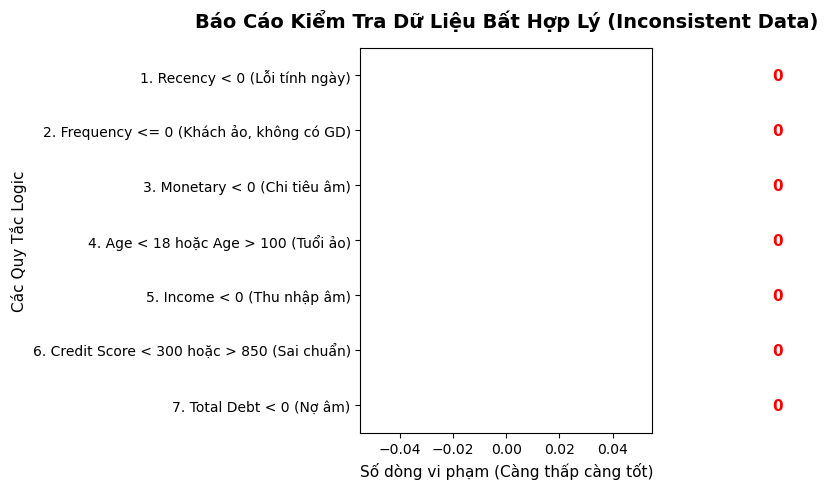

--------------------------------------------------------------------------------


In [9]:
# ==============================================================================
# KIỂM TRA LỖI LOGIC NGHIỆP VỤ (INCONSISTENT DATA) VÀ TRỰC QUAN HÓA
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("🕵️ ĐANG QUÉT CÁC LỖI LOGIC KINH DOANH TRONG SIÊU BẢNG...\n")

# 1. ĐỊNH NGHĨA CÁC QUY TẮC LOGIC (BUSINESS RULES)
# Chú ý: Dấu | nghĩa là HOẶC (Or)
inconsistencies = {
    '1. Recency < 0 (Lỗi tính ngày)': (df_master['Recency'] < 0).sum(),
    '2. Frequency <= 0 (Khách ảo, không có GD)': (df_master['Frequency'] <= 0).sum(),
    '3. Monetary < 0 (Chi tiêu âm)': (df_master['Monetary'] < 0).sum(),
    '4. Age < 18 hoặc Age > 100 (Tuổi ảo)': ((df_master['current_age'] < 18) | (df_master['current_age'] > 100)).sum(),
    '5. Income < 0 (Thu nhập âm)': (df_master['yearly_income'] < 0).sum(),
    '6. Credit Score < 300 hoặc > 850 (Sai chuẩn)': ((df_master['credit_score'] < 300) | (df_master['credit_score'] > 850)).sum(),
    '7. Total Debt < 0 (Nợ âm)': (df_master['total_debt'] < 0).sum()
}

# Chuyển đổi thành DataFrame để dễ báo cáo
df_incon = pd.DataFrame(list(inconsistencies.items()), columns=['Quy Tắc Vi Phạm', 'Số Lượng Dòng'])

print("📋 BẢNG BÁO CÁO KIỂM TRA LOGIC:")
display(df_incon)

# 2. TRỰC QUAN HÓA BÁO CÁO
print("\n📊 ĐANG VẼ BIỂU ĐỒ TỔNG KẾT...")
plt.figure(figsize=(10, 5))

# Vẽ biểu đồ thanh ngang (Barplot)
ax = sns.barplot(x='Số Lượng Dòng', y='Quy Tắc Vi Phạm', data=df_incon, color='salmon')

# Trang trí biểu đồ
plt.title('Báo Cáo Kiểm Tra Dữ Liệu Bất Hợp Lý (Inconsistent Data)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số dòng vi phạm (Càng thấp càng tốt)', fontsize=11)
plt.ylabel('Các Quy Tắc Logic', fontsize=11)

# Thêm con số trực tiếp lên thanh biểu đồ
for p in ax.patches:
    width = p.get_width()
    # Chỉ in số nếu lớn hơn 0, hoặc in số 0 ở ngay sát trục tọa độ
    plt.text(width + 0.1 if width > 0 else 0.1, 
             p.get_y() + p.get_height() / 2, 
             f'{int(width)}', 
             va='center', fontsize=11, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

print("-" * 80)

# 4. Kiểm tra Imbalanced 

⚖️ ĐANG QUÉT SỰ CHÊNH LỆCH THANG ĐO GIỮA CÁC ĐẶC TRƯNG...



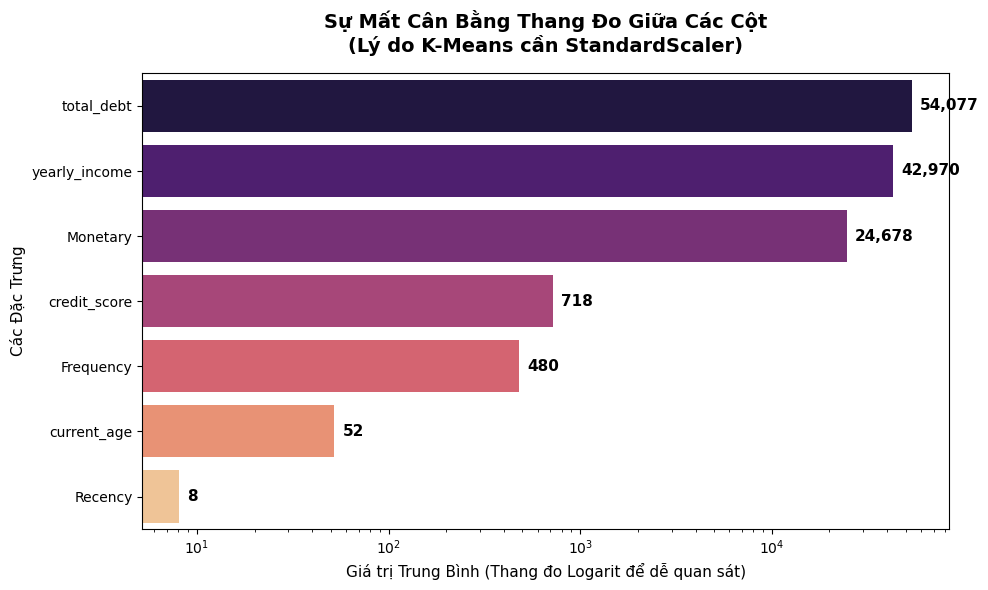

--------------------------------------------------------------------------------
✅ Hoàn tất! Sự chênh lệch cực lớn giữa Income/Debt/Monetary và Age đã lộ diện.


In [10]:
# ==============================================================================
# KIỂM TRA SỰ MẤT CÂN BẰNG THANG ĐO (SCALE IMBALANCE)
# Mục đích: Chứng minh sự chênh lệch đơn vị tính để chuẩn bị cho StandardScaler
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("⚖️ ĐANG QUÉT SỰ CHÊNH LỆCH THANG ĐO GIỮA CÁC ĐẶC TRƯNG...\n")

# 1. Lấy các cột số cần chạy K-Means (bỏ client_id)
num_cols = df_master.select_dtypes(include=[np.number]).columns
cols_to_plot = [col for col in num_cols if col != 'client_id']

# 2. Tính giá trị trung bình của từng cột để so sánh quy mô
means = df_master[cols_to_plot].mean().sort_values(ascending=False)

# 3. Trực quan hóa bằng biểu đồ cột ngang
plt.figure(figsize=(10, 6))

# Vẽ Barplot
ax = sns.barplot(x=means.values, y=means.index, palette='magma')

# Trang trí
plt.title('Sự Mất Cân Bằng Thang Đo Giữa Các Cột\n(Lý do K-Means cần StandardScaler)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Giá trị Trung Bình (Thang đo Logarit để dễ quan sát)', fontsize=11)
plt.ylabel('Các Đặc Trưng', fontsize=11)

# Chuyển trục X sang hệ Logarit vì sự chênh lệch quá khủng khiếp 
# (Tiền thì hàng trăm ngàn, Tuổi thì chỉ vài chục)
plt.xscale('log')

# Hiển thị con số thực tế lên cuối mỗi thanh bar
for p in ax.patches:
    width = p.get_width()
    # Định dạng số có dấu phẩy ngăn cách hàng nghìn
    plt.text(width + (width * 0.1), 
             p.get_y() + p.get_height() / 2, 
             f'{int(width):,}', 
             va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print("-" * 80)
print("✅ Hoàn tất! Sự chênh lệch cực lớn giữa Income/Debt/Monetary và Age đã lộ diện.")

Nhận xét mức độ chênh lệch (Scale Imbalance)
Thực trạng: Biểu đồ cho thấy sự chênh lệch biên độ khổng lồ. Nhóm biến tài chính (yearly_income, total_debt, Monetary) áp đảo hoàn toàn với giá trị hàng chục ngàn, đè bẹp các biến như current_age hay Recency (chỉ ở mức vài chục).

Kết luận: Bắt buộc phải sử dụng StandardScaler ở bước tiếp theo để ép tất cả các đặc trưng về cùng một hệ quy chiếu, tránh việc thuật toán K-Means tính toán sai khoảng cách do lệch đơn vị.

# FEATURE UNDERSTANDING (EDA)

#  Độ tuổi của khách hàng 


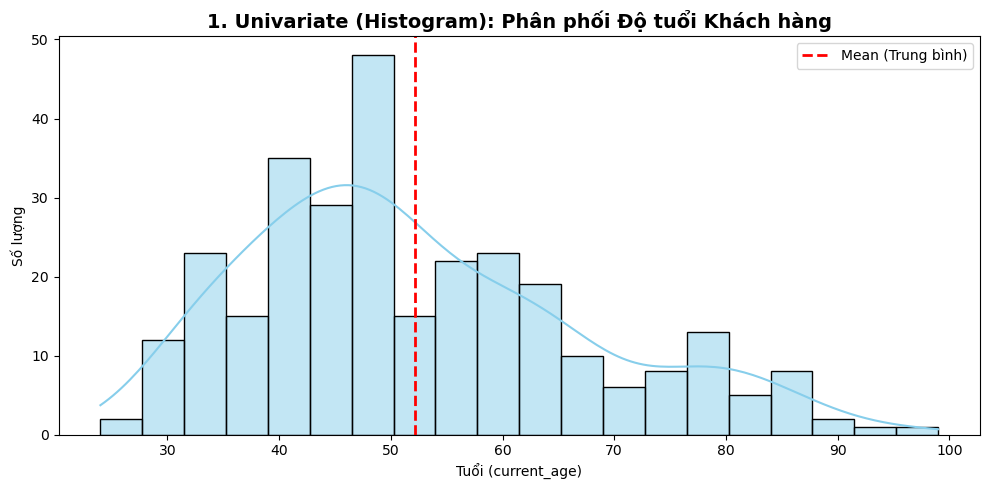

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. UNIVARIATE - HISTOGRAM: Phân phối Độ tuổi (Age)
plt.figure(figsize=(10, 5))
sns.histplot(df_master['current_age'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('1. Univariate (Histogram): Phân phối Độ tuổi Khách hàng', fontsize=14, fontweight='bold')
plt.xlabel('Tuổi (current_age)')
plt.ylabel('Số lượng')
plt.axvline(df_master['current_age'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean (Trung bình)')
plt.legend()
plt.tight_layout()
plt.show()

# Điểm tín dụng 

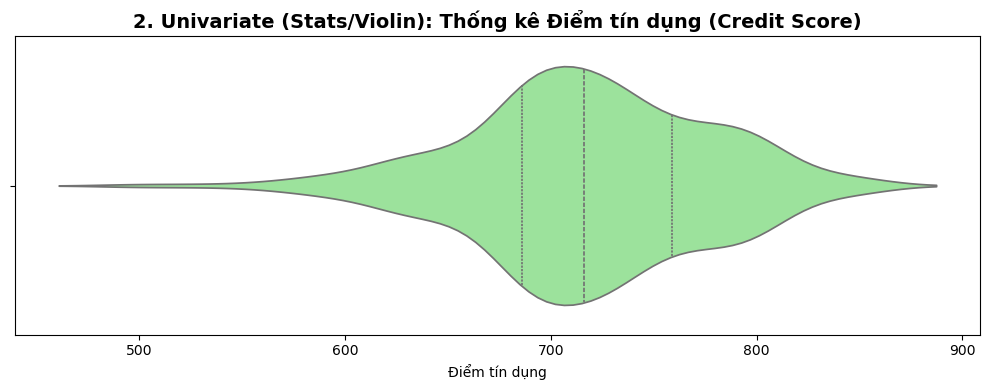

In [5]:
# 2. UNIVARIATE - STATS (VIOLIN PLOT): Thống kê Điểm tín dụng
plt.figure(figsize=(10, 4))
sns.violinplot(x=df_master['credit_score'], color='lightgreen', inner="quartile")
plt.title('2. Univariate (Stats/Violin): Thống kê Điểm tín dụng (Credit Score)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm tín dụng')
plt.tight_layout()
plt.show()

# Mối quan hệ giữa Tần suất giao dịch và Số tiền 

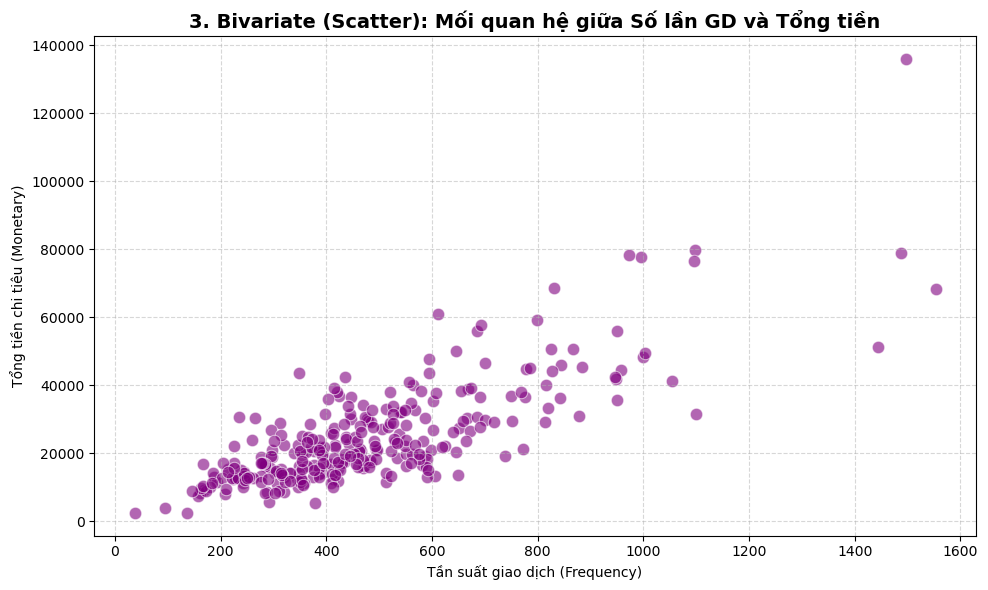

In [6]:
# 3. BIVARIATE - SCATTER PLOT: Mối quan hệ giữa Số lần GD và Tổng tiền
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Frequency', y='Monetary', data=df_master, color='purple', alpha=0.6, s=80)
plt.title('3. Bivariate (Scatter): Mối quan hệ giữa Số lần GD và Tổng tiền', fontsize=14, fontweight='bold')
plt.xlabel('Tần suất giao dịch (Frequency)')
plt.ylabel('Tổng tiền chi tiêu (Monetary)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Biểu đồ Joinplot thể hiện mối quan hệ giữa Thu nhập và Số nợ

<Figure size 800x800 with 0 Axes>

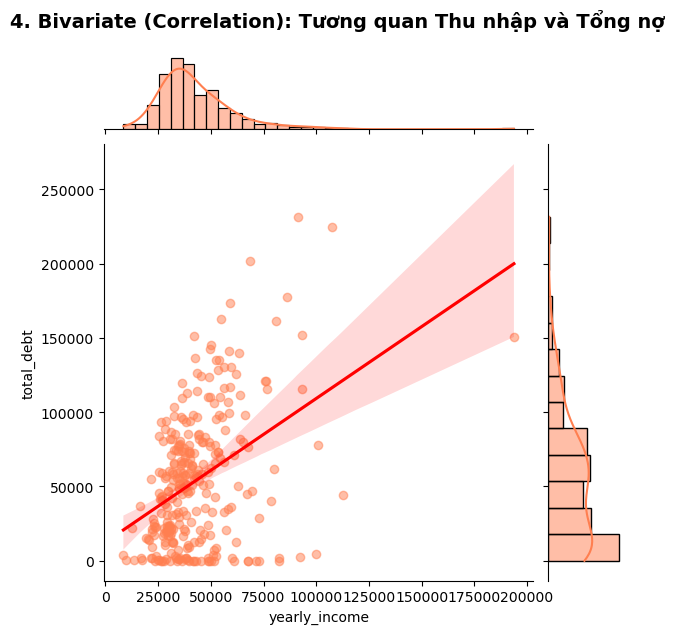

In [7]:
# 4. BIVARIATE - CORRELATION (JOINTPLOT): Tương quan Thu nhập và Tổng nợ
plt.figure(figsize=(8, 8))
g = sns.jointplot(x='yearly_income', y='total_debt', data=df_master, kind='reg', 
                  color='coral', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
g.figure.suptitle('4. Bivariate (Correlation): Tương quan Thu nhập và Tổng nợ', fontsize=14, fontweight='bold', y=1.05)
plt.show()

# Biểu đồ Heatmap thể hiện mối tương quan giữa các biến 

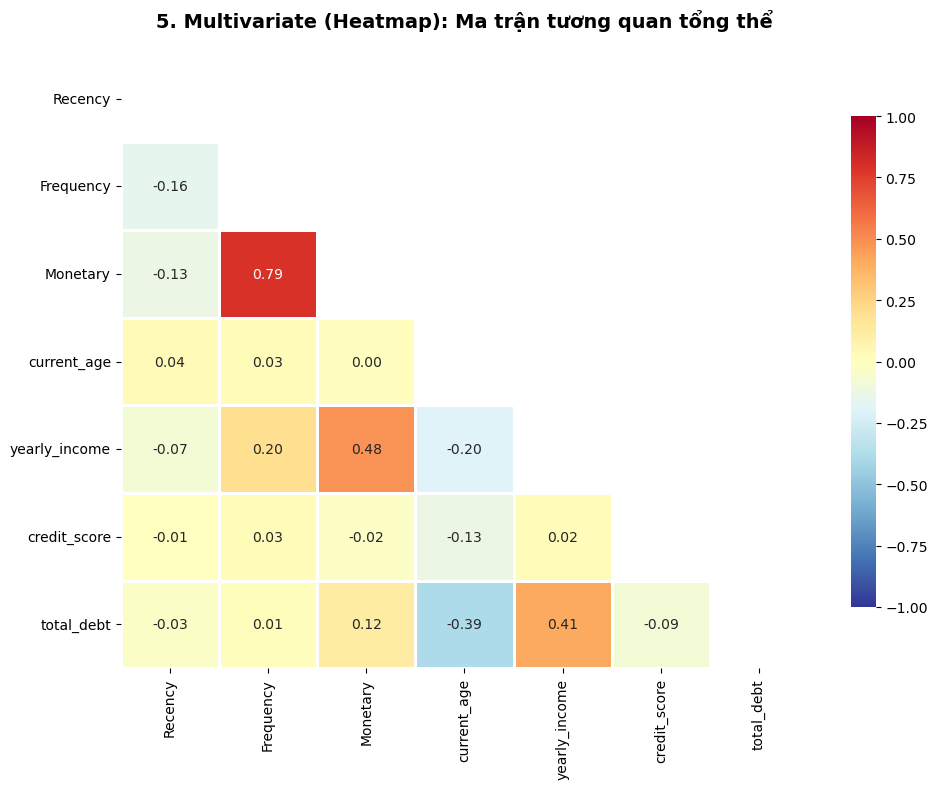

In [8]:
# 5. MULTIVARIATE - HEATMAP: Bức tranh toàn cảnh (Tất cả các biến)
# Lấy danh sách cột số (bỏ client_id) để tính ma trận
num_cols = df_master.select_dtypes(include=[np.number]).columns
cols_to_plot = [col for col in num_cols if col != 'client_id']

plt.figure(figsize=(10, 8))
corr_matrix = df_master[cols_to_plot].corr()

# Tạo Mask để che đi nửa trên của Heatmap (tránh trùng lặp đối xứng)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', fmt=".2f", 
            linewidths=1, cbar_kws={"shrink": .8}, vmin=-1, vmax=1)
plt.title('5. Multivariate (Heatmap): Ma trận tương quan tổng thể', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()